## Analyzing Brazilian E-Commerce Dynamics  

**Objective**: Investigate customer behavior, seller performance, and operational bottlenecks in Olist’s marketplace using real-world transactional data.  

**Dataset**: Includes 100k+ orders, 9 relational tables (customers, sellers, products, reviews, etc.).  

**Methodology**:  
1. **Data Cleaning**: Geolocation validation, payment anomaly detection, null & empty entry analysis.  
2. **EDA**: Customer segmentation, delivery time vs. satisfaction trends.  
3. **Hypothesis Testing**: Pricing bias across regions, seller efficiency impact.  
4. **Advanced Analytics**: PCA for customer behavior patterns.  

**Business Impact**: Recommendations for improving customer retention, delivery logistics, and seller performance.  

In [1]:
# Core Imports
import os
import shutil
import zipfile
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
%matplotlib inline

# Statistical Analysis
from scipy import stats
from scipy.stats import spearmanr, kruskal

# Machine Learning & Dimensionality Reduction
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.decomposition import PCA
import umap.umap_ as umap

# Kaggle Dataset Download
import kagglehub

In [2]:
try:
    dataset_path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
    print(f'Dataset downloaded to {dataset_path}')

    if zipfile.is_zipfile(dataset_path):
        with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
            zip_ref.extractall('data/')
            print(f'Dataset extracted to data/ directory')
    else:
        print('Downloaded file is not a zip archive.')
except Exception as e:
    print(f'Error downloading dataset: {e}')
    print("Alternative: Download manually from https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce")

Dataset downloaded to /home/krmsh1n5/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2
Downloaded file is not a zip archive.


In [3]:
data_files = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "product_category_name": "product_category_name_translation.csv",
}

datasets = {}
try:
    for name, file in data_files.items():
        file_path = os.path.join(dataset_path, file)
        datasets[name] = pd.read_csv(file_path, encoding='latin-1')
        print(f"Loaded {name} dataset: {datasets[name].shape}")
except FileNotFoundError as e:
    print(f'File not found: {e}')
    print("Verify dataset files are in /data directory")

Loaded customers dataset: (99441, 5)
Loaded geolocation dataset: (1000163, 5)
Loaded order_items dataset: (112650, 7)
Loaded order_payments dataset: (103886, 5)
Loaded order_reviews dataset: (99224, 7)
Loaded orders dataset: (99441, 8)
Loaded products dataset: (32951, 9)
Loaded sellers dataset: (3095, 4)
Loaded product_category_name dataset: (71, 2)


## 1 Null Values & Empty Entries Handling  
**Objective**: Address missing and invalid data to ensure dataset reliability and consistency.  
**Method**:  
- Dropped columns with excessive nulls (e.g., `review_comment_title`, `review_comment_message`).  
- Imputed missing timestamps in `cleaned_orders` using median delays and estimated delivery dates.  
- Removed rows with untranslated product categories and manually added missing translations.  
- Ensured all critical fields (e.g., `order_id`, `customer_id`) are complete.  
**Impact**: Improved data quality for accurate analysis, reducing potential biases in customer behavior and operational insights.  

In [4]:
for df_name, df in datasets.items():
    print(f"Dataset: {df_name}")
    print(f"DataFrame shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"First 5 rows:\n{df.head()}")
    print("Missing values:")
    null_counts = df.isnull().sum()
    null_percentage = df.isnull().mean() * 100
    missing_info = pd.DataFrame({'Total Missing': null_counts, 'Percentage': null_percentage})
    print(missing_info)
    print("-" * 40)

Dataset: customers
DataFrame shape: (99441, 5)
Columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
First 5 rows:
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas

In [5]:
cleaned_order_reviews = datasets["order_reviews"].drop(['review_comment_title', 'review_comment_message'], axis=1)

In [6]:
cleaned_orders = datasets["orders"]

approval_delay = (pd.to_datetime(cleaned_orders['order_approved_at']) - 
                  pd.to_datetime(cleaned_orders['order_purchase_timestamp'])).median()

cleaned_orders['order_approved_at'] = cleaned_orders['order_approved_at'].fillna(
    pd.to_datetime(cleaned_orders['order_purchase_timestamp']) + approval_delay
)

remaining_missing = cleaned_orders['order_delivered_carrier_date'].isnull()
cleaned_orders.loc[remaining_missing, 'order_delivered_carrier_date'] = \
    pd.to_datetime(cleaned_orders['order_approved_at']) + pd.Timedelta(days=1)

delivery_time = (pd.to_datetime(cleaned_orders['order_delivered_customer_date']) - 
                 pd.to_datetime(cleaned_orders['order_delivered_carrier_date'])).median()

cleaned_orders['order_delivered_customer_date'] = cleaned_orders['order_delivered_customer_date'].fillna(
    pd.to_datetime(cleaned_orders['order_delivered_carrier_date']) + delivery_time
)

cleaned_orders['order_delivered_customer_date'] = cleaned_orders['order_delivered_customer_date'].fillna(
    cleaned_orders['order_estimated_delivery_date']
)

In [7]:
cleaned_orders['order_purchase_timestamp'] = pd.to_datetime(cleaned_orders['order_purchase_timestamp'])
cleaned_orders['order_approved_at'] = pd.to_datetime(cleaned_orders['order_approved_at'])
cleaned_orders['order_delivered_carrier_date'] = pd.to_datetime(cleaned_orders['order_delivered_carrier_date'])
cleaned_orders['order_delivered_customer_date'] = pd.to_datetime(cleaned_orders['order_delivered_customer_date'])

print(cleaned_orders[['order_approved_at', 
             'order_delivered_carrier_date',
             'order_delivered_customer_date']].isnull().sum())

order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
dtype: int64


In [8]:
cleaned_products = datasets['products'].copy()
cleaned_product_category_name = datasets['product_category_name']
cleaned_product_category_name.rename(columns={'ï»¿product_category_name': 'product_category_name'}, inplace=True)

missing_translations = cleaned_products[~cleaned_products['product_category_name'].isin(
    cleaned_product_category_name['product_category_name']
)]

if not missing_translations.empty:
    print(f"Untranslated categories found: {missing_translations['product_category_name'].unique()}")

manual_translations = pd.DataFrame({
    'product_category_name': ['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'],
    'product_category_name_english': ['PC Gamer', 'Portable Kitchen and Food Preparers']
})

cleaned_product_category_name = pd.concat([cleaned_product_category_name, manual_translations], ignore_index=True)

print(cleaned_product_category_name.tail())

Untranslated categories found: [nan 'pc_gamer' 'portateis_cozinha_e_preparadores_de_alimentos']
                            product_category_name  \
68                                fraldas_higiene   
69                  fashion_roupa_infanto_juvenil   
70                             seguros_e_servicos   
71                                       pc_gamer   
72  portateis_cozinha_e_preparadores_de_alimentos   

          product_category_name_english  
68                  diapers_and_hygiene  
69            fashion_childrens_clothes  
70                security_and_services  
71                             PC Gamer  
72  Portable Kitchen and Food Preparers  


In [9]:
cleaned_products.dropna(subset=['product_category_name'], inplace=True)
cleaned_products.dropna(subset=['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'], inplace=True)
cleaned_products.drop(['product_description_lenght', 'product_name_lenght', 'product_photos_qty'], axis=1, inplace=True)

In [10]:
for df_name, df in [("cleaned_products", cleaned_products), 
                    ("cleaned_orders", cleaned_orders), 
                    ("cleaned_order_reviews", cleaned_order_reviews)]:
    print(f"Dataset: {df_name}")
    print(f"DataFrame shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"First 5 rows:\n{df.head()}")
    print("Missing values:")
    null_counts = df.isnull().sum()
    null_percentage = df.isnull().mean() * 100
    missing_info = pd.DataFrame({'Total Missing': null_counts, 'Percentage': null_percentage})
    print(missing_info)
    print("-" * 40)

Dataset: cleaned_products
DataFrame shape: (32340, 6)
Columns: ['product_id', 'product_category_name', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
First 5 rows:
                         product_id  product_category_name  product_weight_g  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria             225.0   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes            1000.0   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer             154.0   
3  cef67bcfe19066a932b7673e239eb23d                  bebes             371.0   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas             625.0   

   product_length_cm  product_height_cm  product_width_cm  
0               16.0               10.0              14.0  
1               30.0               18.0              20.0  
2               18.0                9.0              15.0  
3               26.0                4.0              26.0  
4               20.0

In [11]:
# Check for encoding issues in the cleaned_product_category_name dataset
encoding_issues = cleaned_product_category_name[
    cleaned_product_category_name['product_category_name'].str.contains(r'[^\x00-\x7F]', na=False) |
    cleaned_product_category_name['product_category_name_english'].str.contains(r'[^\x00-\x7F]', na=False)
]

if not encoding_issues.empty:
    print("Encoding issues found in the following rows:")
    display(encoding_issues)
else:
    print("No encoding issues found in the dataset.")

No encoding issues found in the dataset.


In [12]:
# Save the cleaned datasets to CSV files
cleaned_product_category_name.to_csv('cleaned_product_category_name.csv', index=False)
cleaned_products.to_csv('cleaned_products.csv', index=False)
cleaned_orders.to_csv('cleaned_orders.csv', index=False)
cleaned_order_reviews.to_csv('cleaned_order_reviews.csv', index=False)

print("Cleaned datasets have been saved as CSV files.")

Cleaned datasets have been saved as CSV files.


In [13]:
source_files = ['cleaned_product_category_name.csv', 'cleaned_products.csv', 'cleaned_order_reviews.csv', 'cleaned_orders.csv']
destination_folder = 'cleaned_data'

os.makedirs(destination_folder, exist_ok=True)

for source_file in source_files:
    destination_file = os.path.join(destination_folder, source_file)

    try:
        # Move the file to the destination folder
        shutil.move(source_file, destination_file)
        print(f"File '{source_file}' has been moved to '{destination_folder}' successfully.")
    except FileNotFoundError:
        print(f"Error: The file '{source_file}' does not exist.")
    except Exception as e:
        print(f"An error occurred: {e}")

File 'cleaned_product_category_name.csv' has been moved to 'cleaned_data' successfully.
File 'cleaned_products.csv' has been moved to 'cleaned_data' successfully.
File 'cleaned_order_reviews.csv' has been moved to 'cleaned_data' successfully.
File 'cleaned_orders.csv' has been moved to 'cleaned_data' successfully.


In [14]:
data_folder = 'cleaned_data'

csv_files = [file for file in os.listdir(data_folder) if file.endswith('.csv')]

# Check each CSV file for null or empty values
for csv_file in csv_files:
    file_path = os.path.join(data_folder, csv_file)
    try:
        df = pd.read_csv(file_path, encoding='latin-1')
        
        null_counts = df.isnull().sum()
        empty_strings = (df == '').sum()
        
        print(f"\n=== File: {csv_file} ===")
        print(f"Total rows: {len(df):,}")
        
        if null_counts.sum() > 0:
            print("\nNull values per column:")
            print(null_counts[null_counts > 0].to_string())
        else:
            print("\nNo null values found.")
        
        if empty_strings.sum() > 0:
            print("\nEmpty string values per column:")
            print(empty_strings[empty_strings > 0].to_string())
        else:
            print("\nNo empty string values found.")
        
        print("-" * 40)
    except Exception as e:
        print(f"Error processing file {csv_file}: {e}")


=== File: cleaned_orders.csv ===
Total rows: 99,441

No null values found.

No empty string values found.
----------------------------------------

=== File: cleaned_order_reviews.csv ===
Total rows: 99,224

No null values found.

No empty string values found.
----------------------------------------

=== File: cleaned_products.csv ===
Total rows: 32,340

No null values found.

No empty string values found.
----------------------------------------

=== File: cleaned_product_category_name.csv ===
Total rows: 73

No null values found.

No empty string values found.
----------------------------------------


## 2. Geolocation Validation  
**Objective**: Identify invalid customer/seller coordinates to ensure data reliability.  
**Method**:  
- Filter latitudes > 5°N or longitudes < -75°W (Brazil’s approximate bounds).  
- Plot valid/invalid coordinates using Plotly’s `scatter_mapbox`.  
**Impact**: Ensures accurate delivery time analysis by removing unrealistic locations. 

In [15]:
BRAZIL_LAT_RANGE = (-33.75, 5.27)  # South to North
BRAZIL_LNG_RANGE = (-73.99, -34.79) # West to East

geo = datasets['geolocation']

geo['is_valid'] = (
    (geo['geolocation_lat'].between(BRAZIL_LAT_RANGE[0], BRAZIL_LAT_RANGE[1])) & 
    (geo['geolocation_lng'].between(BRAZIL_LNG_RANGE[0], BRAZIL_LNG_RANGE[1]))
)

# Split into valid/invalid datasets
valid_geo = geo[geo['is_valid']]
invalid_geo = geo[~geo['is_valid']]

print(f"Valid entries: {len(valid_geo):,} ({len(valid_geo)/len(geo):.1%})")
print(f"Invalid entries: {len(invalid_geo):,} ({len(invalid_geo)/len(geo):.1%})")

Valid entries: 1,000,121 (100.0%)
Invalid entries: 42 (0.0%)


In [16]:
valid_sample = valid_geo.sample(frac=0.1, random_state=42)
fig = go.Figure()

fig.add_trace(go.Scattermapbox(
    lat=invalid_geo['geolocation_lat'],
    lon=invalid_geo['geolocation_lng'],
    mode='markers',
    marker=dict(size=6, color='red', opacity=0.7), 
    name=f'Invalid Locations ({len(invalid_geo):,})'
))


fig.add_trace(go.Scattermapbox(
    lat=valid_sample['geolocation_lat'],
    lon=valid_sample['geolocation_lng'],
    mode='markers',
    marker=dict(size=4, color='blue', opacity=0.3),
    name=f'Valid Locations (10% sample)'
))

fig.update_layout(
    title=f'Geolocation Validation<br><sup>Showing 10% valid vs full {len(invalid_geo):,} invalid</sup>',
    mapbox=dict(
        style="carto-positron",
        zoom=1.5,
        center=dict(lat=-14.2350, lon=-51.9253)
    ),
    height=700,
    width=900,
    showlegend=True
)


fig.show(renderer="plotly_mimetype")

In [17]:
clean_geo = geo[geo['is_valid']].drop(columns=['is_valid'])
clean_geo.to_csv('cleaned_geolocation.csv', index=False)

In [18]:
source_file = 'cleaned_geolocation.csv'
destination_folder = 'cleaned_data'

os.makedirs(destination_folder, exist_ok=True)

destination_file = os.path.join(destination_folder, source_file)

try:
    # Move the file to the destination folder
    shutil.move(source_file, destination_file)
    print(f"File '{source_file}' has been moved to '{destination_folder}' successfully.")
except FileNotFoundError:
    print(f"Error: The file '{source_file}' does not exist.")
except Exception as e:
    print(f"An error occurred: {e}")

File 'cleaned_geolocation.csv' has been moved to 'cleaned_data' successfully.


## 3. Payment Value Anomalies  
**Objective**: Detect pricing errors or discounts not reflected in `payment_value`.  
**Method**:  
- Flag orders where `abs(payment_value - (price + freight_value)) > 0.1 * (price + freight_value)`.  
- Analyze anomalies by product category (e.g., electronics vs. furniture).  
**Impact**: Highlights potential fraud or data entry issues affecting revenue reporting. 

In [24]:
order_items = datasets['order_items']
payments = datasets['order_payments']
cleaned_products = pd.read_csv(os.path.join(data_folder, 'cleaned_products.csv'), usecols=['product_id', 'product_category_name'])

In [25]:
order_totals = order_items.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum')
).reset_index()

payment_totals = payments.groupby('order_id')['payment_value'].sum().reset_index()

merged_data = pd.merge(order_totals, payment_totals, on='order_id')

merged_data = pd.merge(merged_data, 
                       order_items[['order_id', 'product_id']].drop_duplicates(),
                       on='order_id')

merged_data = pd.merge(merged_data, cleaned_products, on='product_id')

In [26]:
merged_data['expected_total'] = merged_data['total_price'] + merged_data['total_freight']
merged_data['difference'] = merged_data['payment_value'] - merged_data['expected_total']
merged_data['abs_difference'] = abs(merged_data['difference'])
merged_data['threshold'] = 0.1 * merged_data['expected_total']

merged_data['is_anomaly'] = merged_data['abs_difference'] > merged_data['threshold']

anomalies = merged_data[merged_data['is_anomaly']]

print(f"Total orders: {len(merged_data):,}")
print(f"Anomalous orders: {len(anomalies):,} ({len(anomalies)/len(merged_data):.1%})")

Total orders: 100,963
Anomalous orders: 136 (0.1%)


In [27]:
category_analysis = anomalies.groupby('product_category_name').agg(
    anomaly_count=('order_id', 'nunique'),
    avg_difference=('difference', 'mean')
).sort_values('anomaly_count', ascending=False).reset_index()

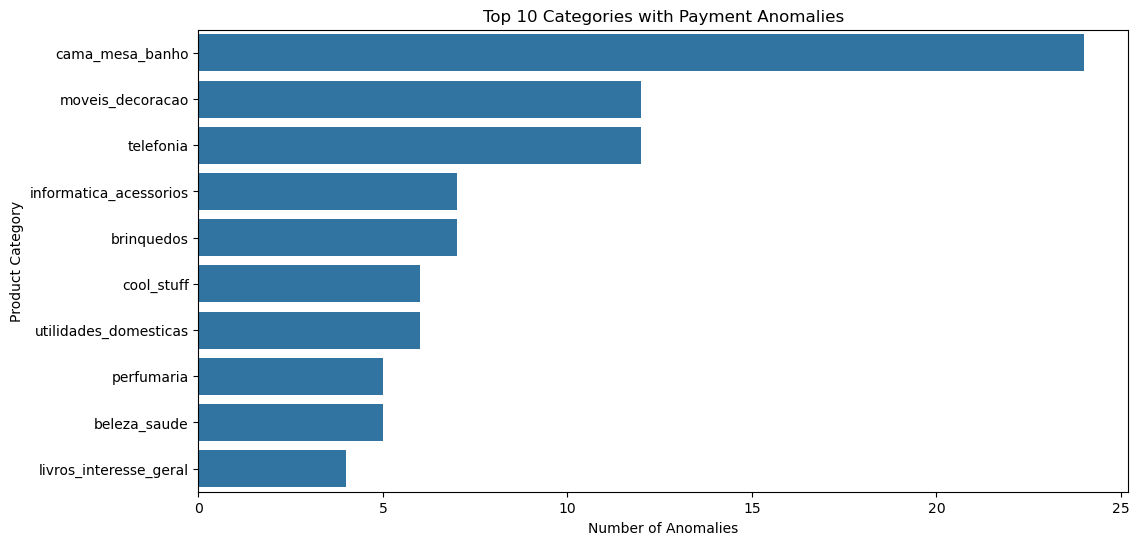


Sample Anomalies:


,order_id,product_category_name,expected_total,payment_value,difference
55382,8d2a68ca0ac61329c56e0b74695b04b4,moveis_decoracao,66.01,72.90,6.89
33055,53e57107ef6a155ab06400be24aa7922,alimentos,112.27,129.68,17.41
44419,70b742795bc441e94a44a084b6d9ce7a,pet_shop,466.93,578.82,111.89


In [28]:
plt.figure(figsize=(12, 6))
sns.barplot(data=category_analysis.head(10), 
            x='anomaly_count', 
            y='product_category_name', 
            )
plt.title('Top 10 Categories with Payment Anomalies')
plt.xlabel('Number of Anomalies')
plt.ylabel('Product Category')
plt.show()

sample_anomalies = anomalies.sample(3, random_state=42)[[
    'order_id', 'product_category_name', 
    'expected_total', 'payment_value', 'difference'
]]
print("\nSample Anomalies:")
display(sample_anomalies)

In [29]:
anomalous_orders = merged_data[merged_data['is_anomaly']]['order_id'].unique()

order_items = datasets['order_items']
cleaned_order_items = order_items[~order_items['order_id'].isin(anomalous_orders)]

payments = datasets['order_payments']
cleaned_payments = payments[~payments['order_id'].isin(anomalous_orders)]

orders = pd.read_csv(os.path.join(data_folder, 'cleaned_orders.csv'))
clean_orders = orders[~orders['order_id'].isin(anomalous_orders)]

cleaned_order_items.to_csv('cleaned_order_items.csv', index=False)
cleaned_payments.to_csv('cleaned_order_payments.csv', index=False)
clean_orders.to_csv('cleaned_orders.csv', index=False)

In [30]:
source_file = ['cleaned_order_payments.csv', 'cleaned_order_items.csv', 'cleaned_orders.csv']
destination_folder = 'cleaned_data'

os.makedirs(destination_folder, exist_ok=True)

for item in source_file:
    source_file = item

    destination_file = os.path.join(destination_folder, source_file)

    try:
        # Move the file to the destination folder
        shutil.move(source_file, destination_file)
        print(f"File '{source_file}' has been moved to '{destination_folder}' successfully.")
    except FileNotFoundError:
        print(f"Error: The file '{source_file}' does not exist.")
    except Exception as e:
        print(f"An error occurred: {e}")

File 'cleaned_order_payments.csv' has been moved to 'cleaned_data' successfully.
File 'cleaned_order_items.csv' has been moved to 'cleaned_data' successfully.
File 'cleaned_orders.csv' has been moved to 'cleaned_data' successfully.


In [31]:
# Calculate financial impact
original_revenue = merged_data['payment_value'].sum()
cleaned_revenue = merged_data[~merged_data['is_anomaly']]['payment_value'].sum()

print(f"\nFinancial Impact:")
print(f"- Original revenue: R${original_revenue:,.2f}")
print(f"- Questionable payments: R${original_revenue - cleaned_revenue:,.2f}")
print(f"- Cleaned revenue: R${cleaned_revenue:,.2f}")


Financial Impact:
- Original revenue: R$16,615,434.95
- Questionable payments: R$21,177.80
- Cleaned revenue: R$16,594,257.15


In [32]:
# Remove previously used variables
del cleaned_order_reviews, cleaned_orders, cleaned_payments, cleaned_product_category_name, cleaned_products
del valid_geo, invalid_geo, geo, merged_data, anomalies, order_totals, payment_totals, order_items, payments

# Combine cleaned datasets
cleaned_data_files = ['cleaned_data/cleaned_orders.csv', 
                      'cleaned_data/cleaned_order_items.csv',
                      'cleaned_data/cleaned_order_payments.csv',
                      'cleaned_data/cleaned_order_reviews.csv', 
                      'cleaned_data/cleaned_products.csv', 
                      'cleaned_data/cleaned_product_category_name.csv', 
                      'cleaned_data/cleaned_geolocation.csv']

cleaned_datasets = {}
for file in cleaned_data_files:
    dataset_name = os.path.basename(file).replace('cleaned_', '').replace('.csv', '')
    cleaned_datasets[dataset_name] = pd.read_csv(file)

# Combine remaining uncleaned datasets
uncleaned_datasets = {name: df for name, df in datasets.items() if name not in cleaned_datasets}

# Merge cleaned and uncleaned datasets into one large dataset
combined_datasets = {**cleaned_datasets, **uncleaned_datasets}

# Display the combined dataset names and their shapes
for name, df in combined_datasets.items():
    print(f"Dataset: {name}, Shape: {df.shape}")

Dataset: orders, Shape: (99313, 8)
Dataset: order_items, Shape: (112503, 7)
Dataset: order_payments, Shape: (103756, 5)
Dataset: order_reviews, Shape: (99224, 5)
Dataset: products, Shape: (32340, 6)
Dataset: product_category_name, Shape: (73, 2)
Dataset: geolocation, Shape: (1000121, 5)
Dataset: customers, Shape: (99441, 5)
Dataset: sellers, Shape: (3095, 4)
